# Probability Distributions and Machine Learning
### *How the shape of your data tells you which model to use*

---

**Choosing a loss function = choosing a probability distribution = making an assumption about your data.**

**Roadmap**
1. What is a loss function, and why do we need one?
2. Where loss functions come from: the shape of your data
3. Bell-curve data → Linear Regression → Squared Error *(sklearn: California Housing)*
4. Binary data → Logistic Regression → Cross-Entropy *(sklearn: Breast Cancer)*
5. Count data → Poisson Regression → Poisson Loss *(sklearn: Bike Sharing)*
6. Positive skewed data → Gamma Regression → Gamma Loss *(sklearn: simulated insurance costs)*
7. Overdispersed counts → Negative Binomial
8. The big picture: a decision guide

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gammaln
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
})
print('Setup complete.')

Setup complete.


---
## 1. What Is a Loss Function, and Why Do We Need One?

A machine learning model learns by making predictions, comparing them to the true answers, and adjusting itself to do better. But "doing better" needs a formal definition. That is the job of the **loss function**: it measures *how wrong* the model's predictions are as a single number.

**The training loop in plain English:**
1. The model makes a prediction: $\hat{y}$
2. We compare it to the truth: $y$
3. The loss function scores how bad this prediction is
4. The model adjusts its parameters to lower that score
5. Repeat until the predictions are good

The most common loss function you will encounter is **Mean Squared Error (MSE)**:
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

It squares the errors so that being off by 2 is penalized 4x as much as being off by 1, and so positive and negative errors do not cancel out.

But here is the question most courses skip: **why squared error? Why not absolute error? Why not cubed error?**

The answer comes from probability.

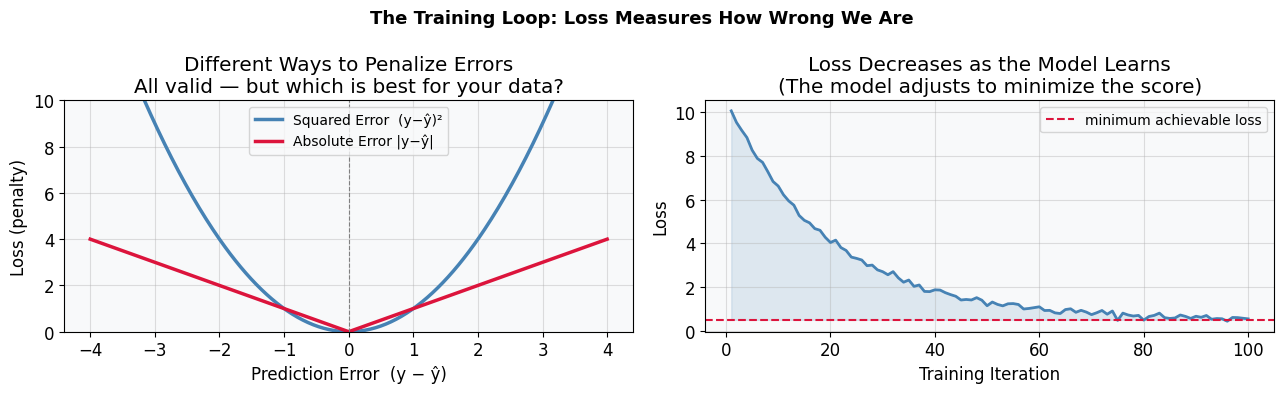

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('The Training Loop: Loss Measures How Wrong We Are', fontsize=13, fontweight='bold')

# Left: different loss functions compared
errors = np.linspace(-4, 4, 300)
axes[0].plot(errors, errors**2,      lw=2.5, color='steelblue', label='Squared Error  (y−ŷ)²')
axes[0].plot(errors, np.abs(errors), lw=2.5, color='crimson',   label='Absolute Error |y−ŷ|')
axes[0].axvline(0, color='gray', lw=0.8, linestyle='--')
axes[0].set_xlabel('Prediction Error  (y − ŷ)')
axes[0].set_ylabel('Loss (penalty)')
axes[0].set_title('Different Ways to Penalize Errors\nAll valid — but which is best for your data?')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 10)

# Right: simulated loss curve over training
iterations = np.arange(1, 101)
loss_curve = 10 * np.exp(-0.05 * iterations) + 0.5 + np.random.normal(0, 0.1, 100)
axes[1].plot(iterations, loss_curve, color='steelblue', lw=2)
axes[1].fill_between(iterations, loss_curve, 0.5, alpha=0.15, color='steelblue')
axes[1].axhline(0.5, color='crimson', lw=1.5, linestyle='--', label='minimum achievable loss')
axes[1].set_xlabel('Training Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Decreases as the Model Learns\n(The model adjusts to minimize the score)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 2. Where Loss Functions Come From: The Shape of Your Data

When a model makes a prediction $\hat{y}$, it is not saying "the answer is exactly $\hat{y}$." It is implicitly saying:

> *"The true value $y$ is probably somewhere near $\hat{y}$, with some uncertainty around it."*

That uncertainty has a **shape**. A good loss function should:
- Be **low** when the model's prediction was close to the truth
- Be **high** when the model was very wrong
- Match the **natural shape** of how errors behave for your specific type of data

This means **different types of outcomes call for different loss functions**, because they have different shapes of uncertainty. Consider:

- Predicting a **house price** — could be off in either direction, spread around the true value
- Predicting whether an email is **spam** — only two options: yes or no
- Predicting **number of bike rentals** — a count, always a non-negative whole number
- Predicting the **cost of an insurance claim** — always positive, with occasional very large values

Each has a different shape. Each calls for a different loss function.

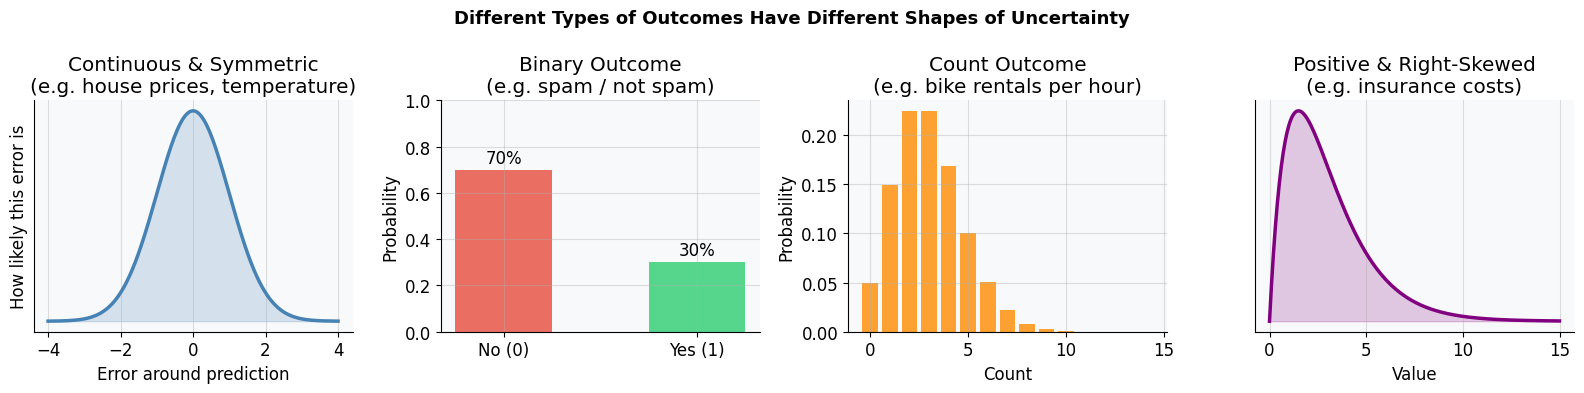

Each shape = a different probability distribution = a different loss function.
The right loss function matches the shape of your outcome variable.


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Different Types of Outcomes Have Different Shapes of Uncertainty',
             fontsize=13, fontweight='bold')

# 1. Continuous, symmetric
xx = np.linspace(-4, 4, 300)
axes[0].plot(xx, stats.norm.pdf(xx, 0, 1), color='steelblue', lw=2.5)
axes[0].fill_between(xx, stats.norm.pdf(xx, 0, 1), alpha=0.2, color='steelblue')
axes[0].set_title('Continuous & Symmetric\n(e.g. house prices, temperature)')
axes[0].set_xlabel('Error around prediction')
axes[0].set_ylabel('How likely this error is')
axes[0].set_yticks([])

# 2. Binary
p = 0.3
axes[1].bar([0, 1], [1-p, p], color=['#e74c3c', '#2ecc71'], width=0.5, alpha=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No (0)', 'Yes (1)'])
axes[1].set_title('Binary Outcome\n(e.g. spam / not spam)')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].text(0, 1-p+0.03, f'{1-p:.0%}', ha='center', fontsize=12)
axes[1].text(1, p+0.03, f'{p:.0%}', ha='center', fontsize=12)

# 3. Counts
k = np.arange(0, 15)
axes[2].bar(k, stats.poisson.pmf(k, 3), color='darkorange', alpha=0.8)
axes[2].set_title('Count Outcome\n(e.g. bike rentals per hour)')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Probability')

# 4. Positive, right-skewed
xx2 = np.linspace(0, 15, 300)
axes[3].plot(xx2, stats.gamma.pdf(xx2, a=2, scale=1.5), color='purple', lw=2.5)
axes[3].fill_between(xx2, stats.gamma.pdf(xx2, a=2, scale=1.5), alpha=0.2, color='purple')
axes[3].set_title('Positive & Right-Skewed\n(e.g. insurance costs)')
axes[3].set_xlabel('Value')
axes[3].set_yticks([])

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Each shape = a different probability distribution = a different loss function.')
print('The right loss function matches the shape of your outcome variable.')

### The connection between probability and loss

Every probability distribution has a formula that scores how likely any value $y$ is, given a prediction $\hat{y}$. A natural training goal is: **make the observed data as probable as possible under the model's predictions.**

It turns out that maximising that probability is mathematically equivalent to minimising a particular loss function — and the specific loss you get depends entirely on which distribution you assumed.

| Distribution assumed | Loss function you minimize |
|---|---|
| Bell-curve (Normal / Gaussian) | Mean Squared Error |
| Coin-flip (Bernoulli) | Binary Cross-Entropy |
| Count data (Poisson) | Poisson Loss |
| Positive skewed (Gamma) | Gamma Loss |
| Overdispersed counts (Negative Binomial) | NB Log-Likelihood |

Let's walk through each one with real data.

---
## 3. Bell-Curve Data → Linear Regression → Squared Error
### *sklearn demo: California Housing dataset*

**The situation:** We want to predict a continuous number that can go up or down — like house prices, temperatures, or exam scores. Our errors tend to cluster symmetrically: we overshoot roughly as often as we undershoot, and by similar amounts.

**The shape that describes this:** The **Normal distribution** (also called the Gaussian, or bell curve). It is symmetric around the mean and tapers off smoothly on both sides.

**Why squared error?**  
If we assume errors follow a bell curve, then making predictions as probable as possible leads *exactly* to minimising the average squared error. Squaring is not arbitrary — it falls out of the bell-curve assumption automatically.

**The sklearn model:** `LinearRegression` — which minimises MSE by default.

California Housing — Linear Regression (MSE loss)
  RMSE = 0.746  (units are $100k, so average error ≈ $75k)
  R²   = 0.576   (1.0 = perfect, 0.0 = just predicting the mean)


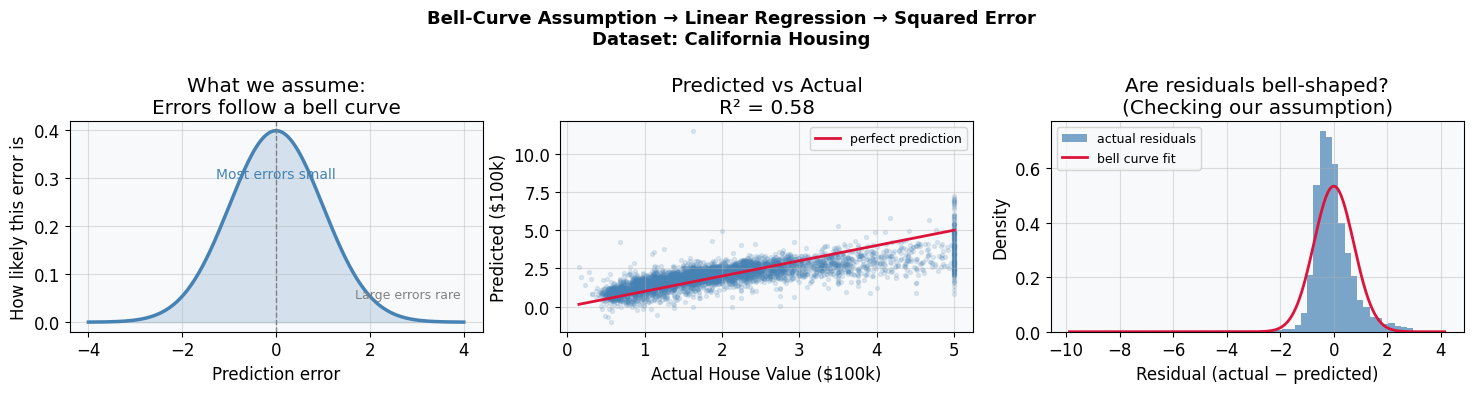


Notice the residuals are roughly bell-shaped but have a longer right tail.
This is common with housing prices — a few very expensive homes pull the errors right.


In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load data
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target  # target = median house value in $100k units

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h_sc = scaler_h.fit_transform(X_train_h)
X_test_h_sc  = scaler_h.transform(X_test_h)

# LinearRegression minimises MSE — equivalent to assuming bell-curve errors
lr_h = LinearRegression()
lr_h.fit(X_train_h_sc, y_train_h)
y_pred_h   = lr_h.predict(X_test_h_sc)
residuals_h = y_test_h - y_pred_h

rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
r2_h   = r2_score(y_test_h, y_pred_h)

print('California Housing — Linear Regression (MSE loss)')
print(f'  RMSE = {rmse_h:.3f}  (units are $100k, so average error ≈ ${rmse_h*100:.0f}k)')
print(f'  R²   = {r2_h:.3f}   (1.0 = perfect, 0.0 = just predicting the mean)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bell-Curve Assumption → Linear Regression → Squared Error\n'
             'Dataset: California Housing', fontsize=13, fontweight='bold')

# Panel 1: The bell curve
xx = np.linspace(-4, 4, 300)
axes[0].plot(xx, stats.norm.pdf(xx, 0, 1), lw=2.5, color='steelblue')
axes[0].fill_between(xx, stats.norm.pdf(xx, 0, 1), alpha=0.2, color='steelblue')
axes[0].set_title('What we assume:\nErrors follow a bell curve')
axes[0].set_xlabel('Prediction error')
axes[0].set_ylabel('How likely this error is')
axes[0].axvline(0, color='gray', lw=1, linestyle='--')
axes[0].annotate('Most errors small', xy=(0, 0.3), ha='center', fontsize=10, color='steelblue')
axes[0].annotate('Large errors rare', xy=(2.8, 0.05), ha='center', fontsize=9, color='gray')

# Panel 2: Predicted vs actual
axes[1].scatter(y_test_h, y_pred_h, alpha=0.15, s=8, color='steelblue')
mn, mx = y_test_h.min(), y_test_h.max()
axes[1].plot([mn, mx], [mn, mx], 'crimson', lw=2, label='perfect prediction')
axes[1].set_xlabel('Actual House Value ($100k)')
axes[1].set_ylabel('Predicted ($100k)')
axes[1].set_title(f'Predicted vs Actual\nR² = {r2_h:.2f}')
axes[1].legend(fontsize=9)

# Panel 3: Do residuals actually look bell-shaped?
axes[2].hist(residuals_h, bins=60, density=True, color='steelblue', alpha=0.7,
             label='actual residuals')
rr = np.linspace(residuals_h.min(), residuals_h.max(), 200)
axes[2].plot(rr, stats.norm.pdf(rr, residuals_h.mean(), residuals_h.std()),
             'crimson', lw=2, label='bell curve fit')
axes[2].set_title('Are residuals bell-shaped?\n(Checking our assumption)')
axes[2].set_xlabel('Residual (actual − predicted)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()
print()
print('Notice the residuals are roughly bell-shaped but have a longer right tail.')
print('This is common with housing prices — a few very expensive homes pull the errors right.')

---
## 4. Binary Data → Logistic Regression → Cross-Entropy Loss
### *sklearn demo: Breast Cancer Wisconsin dataset*

**The situation:** We want to predict a **yes/no** outcome — malignant or benign, spam or not spam, churn or retain. The output is 0 or 1.

**The shape that describes this:** The **Bernoulli distribution** — like a coin flip. The only parameter is the probability of getting a 1 (yes).

**Why not squared error?**  
Squared error treats being wrong by 0.4 the same regardless of direction. But for probabilities, being *confidently* wrong is much worse than being uncertain and wrong. If the true label is 1 and your model says 0.01, that should be a catastrophic penalty — much bigger than if it said 0.45.

The loss that falls out of the Bernoulli assumption is **binary cross-entropy**, which grows very sharply as you become confidently wrong. I like the first six minutes and twenty seconds of [this video](https://www.youtube.com/watch?v=6Qi_9s_dpX8) for a step-by-step explanation of the BCE loss function, which walks through concrete numeric examples and then shows you a plot of the loss function. (The end of the video shows you how to compute the loss with code; it's not necessary for understanding the gist of what the function does).

**The sklearn model:** `LogisticRegression` — despite the name, it is a classifier. It predicts a *probability* between 0 and 1, and minimizes cross-entropy loss.

Breast Cancer Classification — Logistic Regression (cross-entropy loss)
  Accuracy = 97.4%

               precision    recall  f1-score   support

Malignant (0)       0.98      0.95      0.96        43
   Benign (1)       0.97      0.99      0.98        71

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



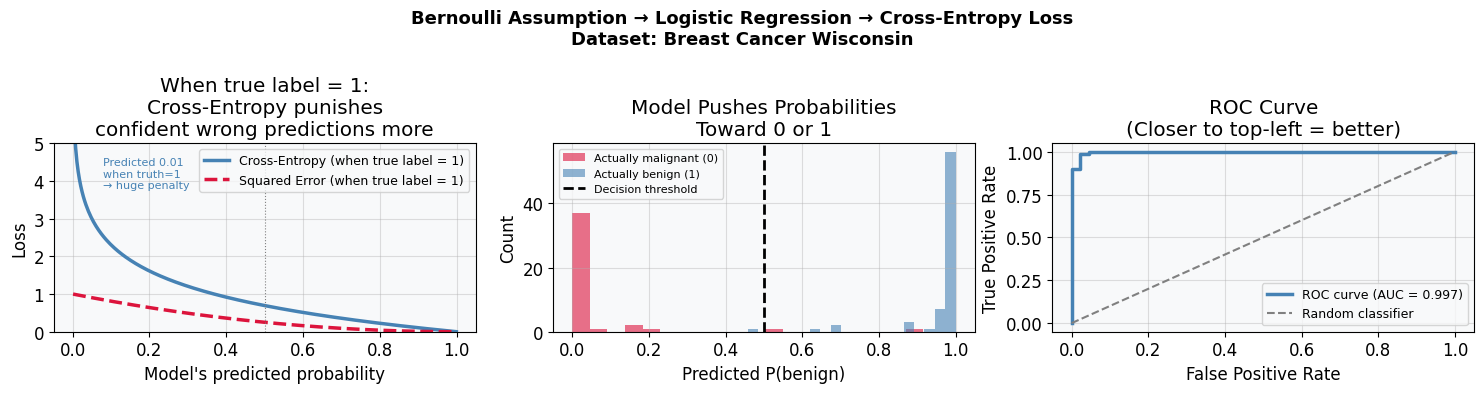

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target   # 0 = malignant, 1 = benign

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42)

scaler_bc = StandardScaler()
X_train_bc_sc = scaler_bc.fit_transform(X_train_bc)
X_test_bc_sc  = scaler_bc.transform(X_test_bc)

# LogisticRegression minimises binary cross-entropy = Bernoulli assumption
lr_bc = LogisticRegression(max_iter=1000, random_state=42)
lr_bc.fit(X_train_bc_sc, y_train_bc)

y_pred_bc  = lr_bc.predict(X_test_bc_sc)
y_proba_bc = lr_bc.predict_proba(X_test_bc_sc)[:, 1]  # P(benign)
acc_bc = accuracy_score(y_test_bc, y_pred_bc)

print('Breast Cancer Classification — Logistic Regression (cross-entropy loss)')
print(f'  Accuracy = {acc_bc:.1%}')
print()
print(classification_report(y_test_bc, y_pred_bc,
                             target_names=['Malignant (0)', 'Benign (1)']))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bernoulli Assumption → Logistic Regression → Cross-Entropy Loss\n'
             'Dataset: Breast Cancer Wisconsin', fontsize=13, fontweight='bold')

# Panel 1: Cross-entropy vs squared error — why cross-entropy is better for binary outcomes
p = np.linspace(0.001, 0.999, 300)
axes[0].plot(p, -np.log(p),   color='steelblue', lw=2.5, label='Cross-Entropy (when true label = 1)')
axes[0].plot(p, (1 - p)**2,   color='crimson',   lw=2.5, linestyle='--',
             label='Squared Error (when true label = 1)')
axes[0].axvline(0.5, color='gray', lw=0.8, linestyle=':')
axes[0].set_xlabel('Model\'s predicted probability')
axes[0].set_ylabel('Loss')
axes[0].set_title('When true label = 1:\nCross-Entropy punishes\nconfident wrong predictions more')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 5)
axes[0].annotate('Predicted 0.01\nwhen truth=1\n→ huge penalty', xy=(0.08, 3.8),
                  fontsize=8, color='steelblue')

# Panel 2: Predicted probabilities by true class
axes[1].hist(y_proba_bc[y_test_bc == 0], bins=20, alpha=0.6,
             color='crimson', label='Actually malignant (0)')
axes[1].hist(y_proba_bc[y_test_bc == 1], bins=20, alpha=0.6,
             color='steelblue', label='Actually benign (1)')
axes[1].axvline(0.5, color='black', lw=2, linestyle='--', label='Decision threshold')
axes[1].set_xlabel('Predicted P(benign)')
axes[1].set_ylabel('Count')
axes[1].set_title('Model Pushes Probabilities\nToward 0 or 1')
axes[1].legend(fontsize=8)

# Panel 3: ROC curve
fpr, tpr, _ = roc_curve(y_test_bc, y_proba_bc)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='steelblue', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'gray', lw=1.5, linestyle='--', label='Random classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve\n(Closer to top-left = better)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Count Data → Poisson Regression → Poisson Loss
### *sklearn demo: Bike Sharing Demand dataset*

**The situation:** We want to predict a **count** — the number of times something happens. Bike rentals per hour. Website visits per day. Support tickets per week. These are always non-negative whole numbers.

**Why can't we use squared error (linear regression)?**
- Linear regression can predict *negative* numbers — impossible for counts
- It assumes the same amount of variability at all values, but counts have more variability when they are larger

**The shape that describes this:** The **Poisson distribution** — built for counts. It has one elegant property: the spread (variance) equals the average (mean). If you expect 10 events on average, the variability is also about 10.

**The sklearn model:** `PoissonRegressor` — it always predicts positive values, and its loss function falls out of the Poisson assumption.

Bike Sharing — Poisson Regression vs Linear Regression
  Poisson Regression MAE : 116.1 rentals
  Linear Regression  MAE : 115.2 rentals
  Negative predictions from Linear Regression: 17 (impossible for a count!)


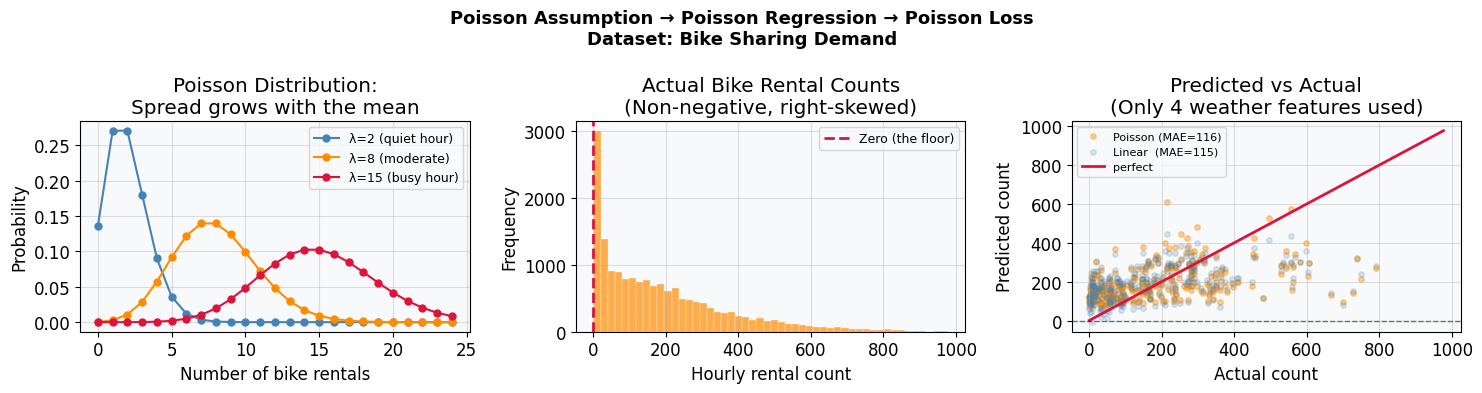

In [7]:
from sklearn.linear_model import PoissonRegressor
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_absolute_error

# Load Bike Sharing dataset
bikes = fetch_openml('Bike_Sharing_Demand', version=2, as_frame=True, parser='auto')
df_bikes = bikes.frame.dropna()

feature_cols = ['temp', 'humidity', 'windspeed']
X_bikes = df_bikes[feature_cols].values.astype(float)
y_bikes = df_bikes['count'].values.astype(float)

X_train_bk, X_test_bk, y_train_bk, y_test_bk = train_test_split(
    X_bikes, y_bikes, test_size=0.2, random_state=42)

scaler_bk = StandardScaler()
X_train_bk_sc = scaler_bk.fit_transform(X_train_bk)
X_test_bk_sc  = scaler_bk.transform(X_test_bk)

# Poisson Regression — correct for count data
pois_reg = PoissonRegressor(alpha=0.01, max_iter=500)
pois_reg.fit(X_train_bk_sc, y_train_bk)
y_pred_pois = pois_reg.predict(X_test_bk_sc)

# Linear Regression for comparison — wrong assumption
lin_reg_bk = LinearRegression()
lin_reg_bk.fit(X_train_bk_sc, y_train_bk)
y_pred_lin_bk = lin_reg_bk.predict(X_test_bk_sc)

mae_pois = mean_absolute_error(y_test_bk, y_pred_pois)
mae_lin  = mean_absolute_error(y_test_bk, y_pred_lin_bk)
neg_preds = (y_pred_lin_bk < 0).sum()

print('Bike Sharing — Poisson Regression vs Linear Regression')
print(f'  Poisson Regression MAE : {mae_pois:.1f} rentals')
print(f'  Linear Regression  MAE : {mae_lin:.1f} rentals')
print(f'  Negative predictions from Linear Regression: {neg_preds} (impossible for a count!)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Poisson Assumption → Poisson Regression → Poisson Loss\n'
             'Dataset: Bike Sharing Demand', fontsize=13, fontweight='bold')

# Panel 1: Poisson distribution shape for different average counts
k = np.arange(0, 25)
for lam, color, label in [(2, 'steelblue', 'λ=2 (quiet hour)'),
                            (8, 'darkorange', 'λ=8 (moderate)'),
                            (15, 'crimson', 'λ=15 (busy hour)')]:
    axes[0].plot(k, stats.poisson.pmf(k, lam), 'o-', ms=5, lw=1.5, color=color, label=label)
axes[0].set_title('Poisson Distribution:\nSpread grows with the mean')
axes[0].set_xlabel('Number of bike rentals')
axes[0].set_ylabel('Probability')
axes[0].legend(fontsize=9)

# Panel 2: Actual count distribution
axes[1].hist(y_bikes, bins=50, color='darkorange', alpha=0.7, edgecolor='white', lw=0.3)
axes[1].set_title('Actual Bike Rental Counts\n(Non-negative, right-skewed)')
axes[1].set_xlabel('Hourly rental count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='crimson', lw=2, linestyle='--', label='Zero (the floor)')
axes[1].legend(fontsize=9)

# Panel 3: Poisson vs Linear predictions
sample_idx = np.random.choice(len(y_test_bk), 300, replace=False)
axes[2].scatter(y_test_bk[sample_idx], y_pred_pois[sample_idx],
                alpha=0.4, s=15, color='darkorange', label=f'Poisson (MAE={mae_pois:.0f})')
axes[2].scatter(y_test_bk[sample_idx], y_pred_lin_bk[sample_idx],
                alpha=0.2, s=15, color='steelblue', label=f'Linear  (MAE={mae_lin:.0f})')
axes[2].plot([y_test_bk.min(), y_test_bk.max()],
             [y_test_bk.min(), y_test_bk.max()], 'crimson', lw=2, label='perfect')
axes[2].axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
axes[2].set_xlabel('Actual count')
axes[2].set_ylabel('Predicted count')
axes[2].set_title('Predicted vs Actual\n(Only 4 weather features used)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

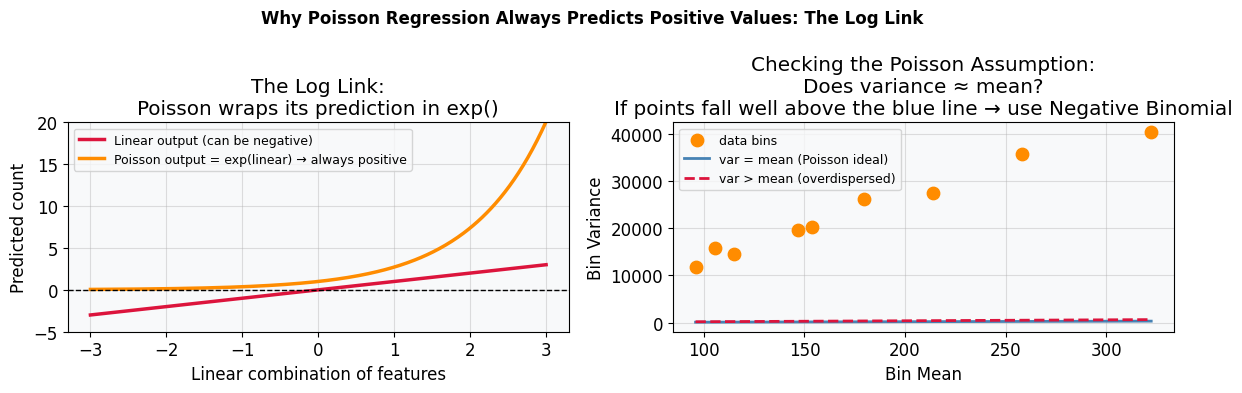

In [8]:
# The log link: why Poisson predictions are always positive
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Why Poisson Regression Always Predicts Positive Values: The Log Link',
             fontsize=12, fontweight='bold')

x_log = np.linspace(-3, 3, 300)
axes[0].plot(x_log, x_log,           color='crimson',   lw=2.5,
             label='Linear output (can be negative)')
axes[0].plot(x_log, np.exp(x_log),   color='darkorange', lw=2.5,
             label='Poisson output = exp(linear) → always positive')
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_xlabel('Linear combination of features')
axes[0].set_ylabel('Predicted count')
axes[0].set_title('The Log Link:\nPoisson wraps its prediction in exp()')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-5, 20)

# Mean ≈ Variance diagnostic
bins = np.percentile(y_pred_pois, np.linspace(10, 90, 10))
bin_idx = np.digitize(y_pred_pois, bins)
b_means = np.array([y_test_bk[bin_idx == i].mean() for i in range(1, len(bins))])
b_vars  = np.array([y_test_bk[bin_idx == i].var()  for i in range(1, len(bins))])
mv_r = np.linspace(b_means.min(), b_means.max(), 100)

axes[1].scatter(b_means, b_vars, s=80, color='darkorange', zorder=5, label='data bins')
axes[1].plot(mv_r, mv_r,     'steelblue', lw=2, label='var = mean (Poisson ideal)')
axes[1].plot(mv_r, 2*mv_r,   'crimson',   lw=2, linestyle='--', label='var > mean (overdispersed)')
axes[1].set_xlabel('Bin Mean')
axes[1].set_ylabel('Bin Variance')
axes[1].set_title('Checking the Poisson Assumption:\nDoes variance ≈ mean?\n'
                   'If points fall well above the blue line → use Negative Binomial')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Positive Skewed Data → Gamma Regression → Gamma Loss
### *sklearn demo: Simulated insurance costs*

**The situation:** We want to predict a **positive, continuous** value where large outcomes are relatively common — insurance claim costs, household income, time to complete a task. These distributions have a long right tail.

**Why squared error fails here:**
- Linear regression can predict negative costs (impossible)
- Squared error treats a thousand dollar error as equally bad whether the true value is two thousand bucks or two hundred thousand bucks. But for costs, we usually care about *relative* accuracy — being off by 10% is equally bad at any scale.

**The shape that describes this:** The **Gamma distribution** — always positive, right-skewed, and with variance that grows with the square of the mean. This means larger costs also have larger absolute variability.

**The sklearn model:** `GammaRegressor` — uses a log link (like Poisson) to ensure positive predictions, but with a loss derived from the Gamma distribution.

Insurance Costs — Gamma Regression vs Linear Regression
  Gamma Regression MAPE  : 113.8%  (mean absolute percentage error)
  Linear Regression MAPE : 139.4%
  Negative cost predictions from Linear Regression: 40


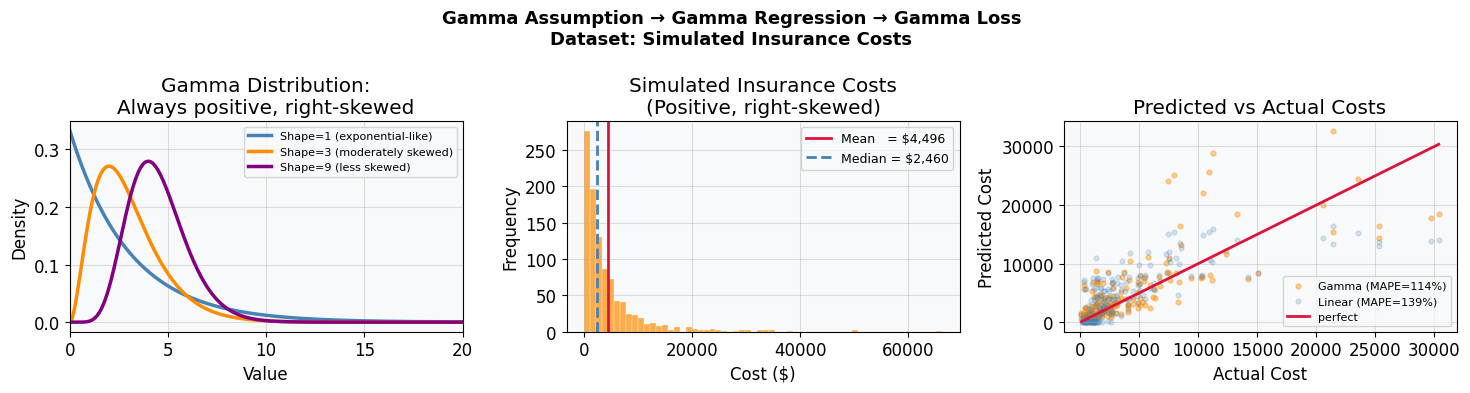


Note: Mean >> Median signals a right-skewed distribution.
A handful of very large claims pull the mean up — exactly what the Gamma captures.


In [9]:
from sklearn.linear_model import GammaRegressor

# Simulate insurance cost data
np.random.seed(42)
n_ins = 1000
age    = np.random.uniform(18, 70, n_ins)
bmi    = np.random.normal(28, 6, n_ins)
smoker = np.random.binomial(1, 0.2, n_ins)

# Costs are multiplicative: log(cost) is linear in features
log_mu  = 0.05 * age + 0.02 * bmi + 1.2 * smoker + 5
mu_ins  = np.exp(log_mu)
y_ins   = np.random.gamma(shape=3.0, scale=mu_ins / 3.0)

X_ins = np.column_stack([age, bmi, smoker])
X_train_ins, X_test_ins, y_train_ins, y_test_ins = train_test_split(
    X_ins, y_ins, test_size=0.2, random_state=42)

scaler_ins = StandardScaler()
X_train_ins_sc = scaler_ins.fit_transform(X_train_ins)
X_test_ins_sc  = scaler_ins.transform(X_test_ins)

# Gamma Regression — correct for positive skewed costs
gamma_reg = GammaRegressor(alpha=0.01, max_iter=500)
gamma_reg.fit(X_train_ins_sc, y_train_ins)
y_pred_gamma = gamma_reg.predict(X_test_ins_sc)

# Linear Regression for comparison
lin_reg_ins = LinearRegression()
lin_reg_ins.fit(X_train_ins_sc, y_train_ins)
y_pred_lin_ins = lin_reg_ins.predict(X_test_ins_sc)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_gamma = mape(y_test_ins, y_pred_gamma)
mape_lin   = mape(y_test_ins, np.clip(y_pred_lin_ins, 1, None))
neg_ins    = (y_pred_lin_ins < 0).sum()

print('Insurance Costs — Gamma Regression vs Linear Regression')
print(f'  Gamma Regression MAPE  : {mape_gamma:.1f}%  (mean absolute percentage error)')
print(f'  Linear Regression MAPE : {mape_lin:.1f}%')
print(f'  Negative cost predictions from Linear Regression: {neg_ins}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Gamma Assumption → Gamma Regression → Gamma Loss\n'
             'Dataset: Simulated Insurance Costs', fontsize=13, fontweight='bold')

# Panel 1: Gamma distribution shapes
xx = np.linspace(0.01, 20, 400)
for shape, scale, color, label in [
        (1, 3,   'steelblue',  'Shape=1 (exponential-like)'),
        (3, 1,   'darkorange', 'Shape=3 (moderately skewed)'),
        (9, 0.5, 'purple',     'Shape=9 (less skewed)')]:
    axes[0].plot(xx, stats.gamma.pdf(xx, a=shape, scale=scale), lw=2.5, color=color, label=label)
axes[0].set_title('Gamma Distribution:\nAlways positive, right-skewed')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 20)

# Panel 2: Actual cost distribution
axes[1].hist(y_ins, bins=60, color='darkorange', alpha=0.7, edgecolor='white', lw=0.3)
axes[1].set_title('Simulated Insurance Costs\n(Positive, right-skewed)')
axes[1].set_xlabel('Cost ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(y_ins),   color='crimson',   lw=2, label=f'Mean   = ${np.mean(y_ins):,.0f}')
axes[1].axvline(np.median(y_ins), color='steelblue', lw=2, linestyle='--',
                label=f'Median = ${np.median(y_ins):,.0f}')
axes[1].legend(fontsize=9)

# Panel 3: Predicted vs actual
axes[2].scatter(y_test_ins, y_pred_gamma, alpha=0.4, s=12, color='darkorange',
                label=f'Gamma (MAPE={mape_gamma:.0f}%)')
axes[2].scatter(y_test_ins, np.clip(y_pred_lin_ins, 0, None),
                alpha=0.2, s=12, color='steelblue', label=f'Linear (MAPE={mape_lin:.0f}%)')
axes[2].plot([y_test_ins.min(), y_test_ins.max()],
             [y_test_ins.min(), y_test_ins.max()], 'crimson', lw=2, label='perfect')
axes[2].set_xlabel('Actual Cost')
axes[2].set_ylabel('Predicted Cost')
axes[2].set_title('Predicted vs Actual Costs')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print()
print('Note: Mean >> Median signals a right-skewed distribution.')
print('A handful of very large claims pull the mean up — exactly what the Gamma captures.')

---
## 7. When Poisson Is Not Enough: Overdispersed Counts

**The problem:** Poisson regression assumes the variance equals the mean. In practice, count data often has *much more* variability than that. This is called **overdispersion**.

Common examples of overdispersed counts:
- Number of insurance claims filed per customer (most file zero, a few file many)
- Social media shares per post (most get few, some go viral)
- Doctor visits per patient per year

**The fix — Negative Binomial distribution:** It adds an extra parameter that lets variance exceed the mean. When that parameter is large, it reduces back to Poisson. When it is small, there is a lot of extra spread.

**In scikit-learn:** There is no `NegativeBinomialRegressor`. The `TweedieRegressor` with a `power` parameter between 1 and 2 is the closest available option. For a proper Negative Binomial fit, use `statsmodels`.

Overdispersed Count Data — Comparing Poisson vs Tweedie Models
  Dispersion ratio in test set: 6.75
  (Poisson assumes this should be 1.0)

  Poisson (power=1)               MAE = 3.62
  Tweedie (power=1.5)             MAE = 3.62
  Tweedie (power=1.9)             MAE = 3.62


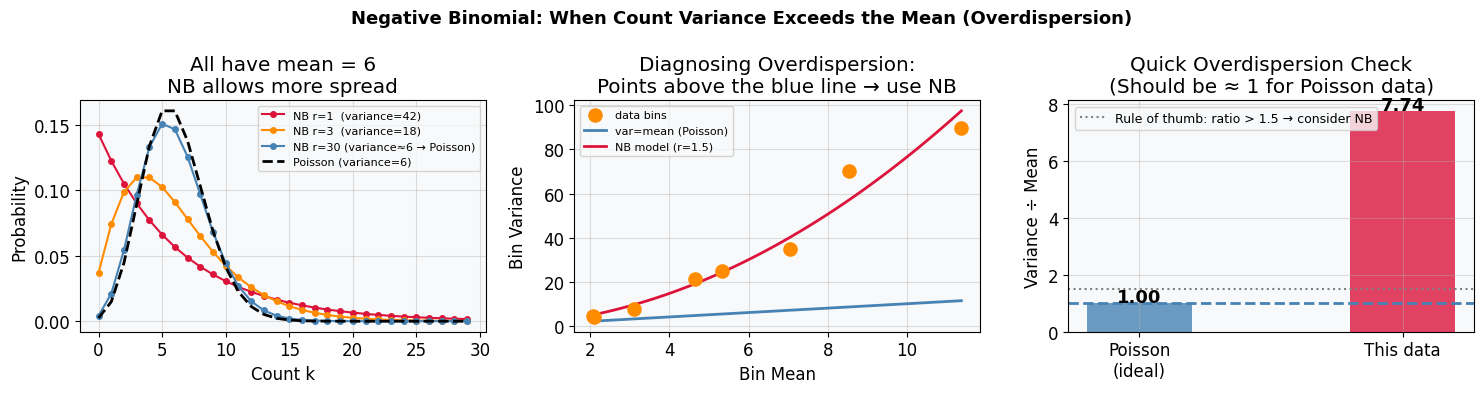

In [10]:
from sklearn.linear_model import TweedieRegressor

# Simulate overdispersed count data
np.random.seed(42)
n_nb = 600
x_nb = np.random.uniform(0, 3, n_nb)
mu_nb_true = np.exp(0.5 + 0.7 * x_nb)
r_true = 1.5  # low r = high overdispersion

# Negative Binomial = Gamma-Poisson mixture
lambda_mix = np.random.gamma(r_true, mu_nb_true / r_true)
y_nb = np.random.poisson(lambda_mix)

X_nb_arr = x_nb.reshape(-1, 1)
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb_arr, y_nb, test_size=0.2, random_state=42)

models_nb = {
    'Poisson (power=1)':   PoissonRegressor(alpha=0, max_iter=500),
    'Tweedie (power=1.5)': TweedieRegressor(power=1.5, alpha=0, max_iter=500),
    'Tweedie (power=1.9)': TweedieRegressor(power=1.9, alpha=0, max_iter=500),
}

print('Overdispersed Count Data — Comparing Poisson vs Tweedie Models')
print(f'  Dispersion ratio in test set: {y_test_nb.var()/y_test_nb.mean():.2f}')
print(f'  (Poisson assumes this should be 1.0)')
print()
for name, model in models_nb.items():
    model.fit(X_train_nb, y_train_nb)
    mae = mean_absolute_error(y_test_nb, model.predict(X_test_nb))
    print(f'  {name:30s}  MAE = {mae:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Negative Binomial: When Count Variance Exceeds the Mean (Overdispersion)',
             fontsize=13, fontweight='bold')

# Panel 1: NB vs Poisson — same mean, very different spread
k = np.arange(0, 30)
mu_demo = 6
for r_val, color, label in [
        (1.0, 'crimson',    f'NB r=1  (variance={mu_demo+mu_demo**2/1:.0f})'),
        (3.0, 'darkorange', f'NB r=3  (variance={mu_demo+mu_demo**2/3:.0f})'),
        (30,  'steelblue',  f'NB r=30 (variance≈{mu_demo:.0f} → Poisson)')]:
    p_suc = r_val / (r_val + mu_demo)
    axes[0].plot(k, stats.nbinom.pmf(k, r_val, p_suc), 'o-', ms=4, lw=1.5,
                 color=color, label=label)
axes[0].plot(k, stats.poisson.pmf(k, mu_demo), 'k--', lw=2, label=f'Poisson (variance={mu_demo})')
axes[0].set_title(f'All have mean = {mu_demo}\nNB allows more spread')
axes[0].set_xlabel('Count k')
axes[0].set_ylabel('Probability')
axes[0].legend(fontsize=8)

# Panel 2: Variance vs mean diagnostic
bins_nb = np.linspace(0, 3, 9)
bidx_nb = np.digitize(x_nb, bins_nb)
b_means_nb = np.array([y_nb[bidx_nb == i].mean() for i in range(1, len(bins_nb)) if (bidx_nb==i).sum()>5])
b_vars_nb  = np.array([y_nb[bidx_nb == i].var()  for i in range(1, len(bins_nb)) if (bidx_nb==i).sum()>5])
mv_r = np.linspace(b_means_nb.min(), b_means_nb.max(), 100)
axes[1].scatter(b_means_nb, b_vars_nb, s=90, color='darkorange', zorder=5, label='data bins')
axes[1].plot(mv_r, mv_r,                    'steelblue', lw=2, label='var=mean (Poisson)')
axes[1].plot(mv_r, mv_r + mv_r**2/r_true,   'crimson',   lw=2,
             label=f'NB model (r={r_true})')
axes[1].set_xlabel('Bin Mean')
axes[1].set_ylabel('Bin Variance')
axes[1].set_title('Diagnosing Overdispersion:\nPoints above the blue line → use NB')
axes[1].legend(fontsize=8)

# Panel 3: Dispersion ratio bar chart
disp_ratio = y_nb.var() / y_nb.mean()
bars = axes[2].bar(['Poisson\n(ideal)', 'This data'],
                    [1.0, disp_ratio],
                    color=['steelblue', 'crimson'], alpha=0.8, width=0.4)
axes[2].axhline(1.0, color='steelblue', lw=2, linestyle='--')
axes[2].axhline(1.5, color='gray',      lw=1.5, linestyle=':',
                label='Rule of thumb: ratio > 1.5 → consider NB')
axes[2].set_ylabel('Variance ÷ Mean')
axes[2].set_title('Quick Overdispersion Check\n(Should be ≈ 1 for Poisson data)')
axes[2].legend(fontsize=9)
for bar, val in zip(bars, [1.0, disp_ratio]):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 8. The Big Picture: A Decision Guide

Everything we have covered belongs to a unified framework called **Generalized Linear Models (GLMs)**. The process is always:

1. **Look at your outcome variable** — what type is it, what shape does it have?
2. **Choose the distribution** that matches that shape
3. **The loss function is determined for you** — it falls out of the distribution
4. **Fit the model** — find the parameters that minimise that loss

You have been doing this throughout. Now you know the reasoning.

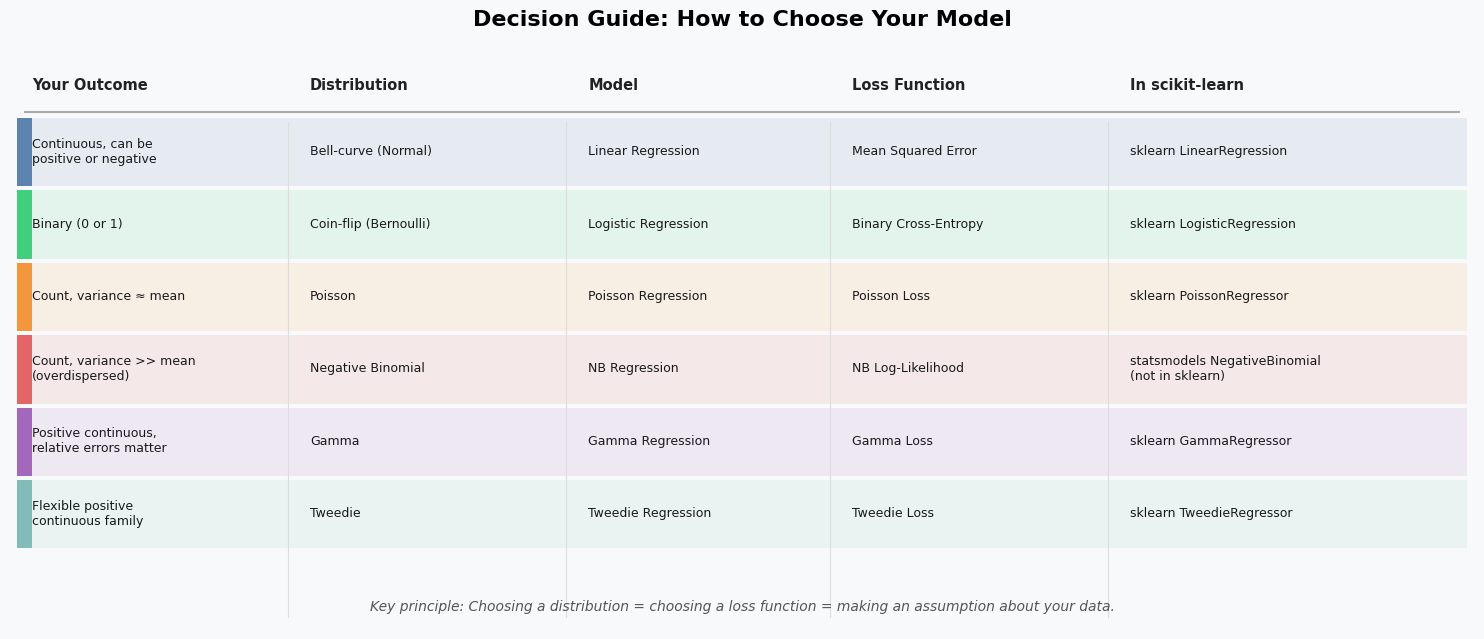

In [11]:
# Decision guide table
fig, ax = plt.subplots(figsize=(15, 6.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Decision Guide: How to Choose Your Model',
             fontsize=16, fontweight='bold', y=0.98)

rows = [
    ('Continuous, can be\npositive or negative',
     'Bell-curve (Normal)',
     'Linear Regression',
     'Mean Squared Error',
     'sklearn LinearRegression',
     '#4e79a7'),
    ('Binary (0 or 1)',
     'Coin-flip (Bernoulli)',
     'Logistic Regression',
     'Binary Cross-Entropy',
     'sklearn LogisticRegression',
     '#2ecc71'),
    ('Count, variance ≈ mean',
     'Poisson',
     'Poisson Regression',
     'Poisson Loss',
     'sklearn PoissonRegressor',
     '#f28e2b'),
    ('Count, variance >> mean\n(overdispersed)',
     'Negative Binomial',
     'NB Regression',
     'NB Log-Likelihood',
     'statsmodels NegativeBinomial\n(not in sklearn)',
     '#e15759'),
    ('Positive continuous,\nrelative errors matter',
     'Gamma',
     'Gamma Regression',
     'Gamma Loss',
     'sklearn GammaRegressor',
     '#9b59b6'),
    ('Flexible positive\ncontinuous family',
     'Tweedie',
     'Tweedie Regression',
     'Tweedie Loss',
     'sklearn TweedieRegressor',
     '#76b7b2'),
]

headers  = ['Your Outcome', 'Distribution', 'Model', 'Loss Function', 'In scikit-learn']
col_x    = [0.15, 2.05, 3.95, 5.75, 7.65]
row_h    = 0.88

for hx, h in zip(col_x, headers):
    ax.text(hx, 6.6, h, fontsize=10.5, fontweight='bold', color='#222222', va='center', ha='left')
ax.axhline(6.28, color='#aaaaaa', lw=1.5, xmin=0.01, xmax=0.99)

for i, (outcome, dist, model, loss, skl, color) in enumerate(rows):
    y_pos = 5.8 - i * row_h
    ax.add_patch(plt.Rectangle((0.05, y_pos - row_h/2 + 0.02), 9.9, row_h - 0.05,
                                facecolor=color, alpha=0.1, zorder=0))
    ax.add_patch(plt.Rectangle((0.05, y_pos - row_h/2 + 0.02), 0.1, row_h - 0.05,
                                facecolor=color, alpha=0.9, zorder=1))
    for cx, val in zip(col_x, [outcome, dist, model, loss, skl]):
        ax.text(cx, y_pos, val, fontsize=9, va='center', ha='left', color='#1a1a1a')

for cx in [1.9, 3.8, 5.6, 7.5]:
    ax.axvline(cx, color='#dddddd', lw=0.8, ymin=0.02, ymax=0.88)

ax.text(5, 0.22,
        'Key principle: Choosing a distribution = choosing a loss function = making an assumption about your data.',
        fontsize=10, ha='center', style='italic', color='#555555')
plt.tight_layout()
plt.show()

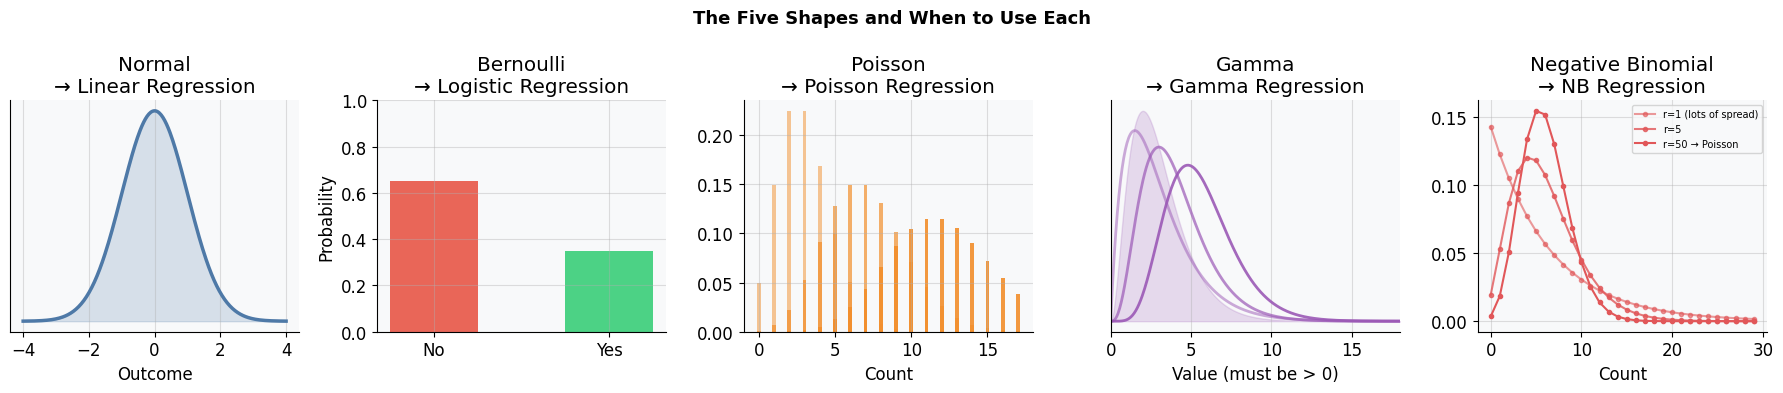

In [12]:
# Side-by-side: all five distribution shapes
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('The Five Shapes and When to Use Each', fontsize=13, fontweight='bold')

# Normal
xx = np.linspace(-4, 4, 300)
axes[0].plot(xx, stats.norm.pdf(xx), color='#4e79a7', lw=2.5)
axes[0].fill_between(xx, stats.norm.pdf(xx), alpha=0.2, color='#4e79a7')
axes[0].set_title('Normal\n→ Linear Regression')
axes[0].set_xlabel('Outcome')
axes[0].set_yticks([])

# Bernoulli
axes[1].bar([0, 1], [0.65, 0.35], color=['#e74c3c', '#2ecc71'], width=0.5, alpha=0.85)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_title('Bernoulli\n→ Logistic Regression')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)

# Poisson
k = np.arange(0, 18)
for lam, alpha in [(3, 0.5), (7, 0.7), (12, 0.9)]:
    axes[2].bar(k, stats.poisson.pmf(k, lam), width=0.25, alpha=alpha, color='#f28e2b')
axes[2].set_title('Poisson\n→ Poisson Regression')
axes[2].set_xlabel('Count')

# Gamma
xx2 = np.linspace(0.01, 20, 400)
axes[3].fill_between(xx2, stats.gamma.pdf(xx2, a=3, scale=1), alpha=0.2, color='#9b59b6')
for shape, scale, alpha in [(2, 1.5, 0.5), (4, 1, 0.7), (7, 0.8, 0.9)]:
    axes[3].plot(xx2, stats.gamma.pdf(xx2, a=shape, scale=scale), lw=2, color='#9b59b6', alpha=alpha)
axes[3].set_title('Gamma\n→ Gamma Regression')
axes[3].set_xlabel('Value (must be > 0)')
axes[3].set_xlim(0, 18)
axes[3].set_yticks([])

# Negative Binomial
k2 = np.arange(0, 30)
mu_show = 6
for r_val, alpha, label in [(1, 0.6, 'r=1 (lots of spread)'),
                              (5, 0.8, 'r=5'),
                              (50, 1.0, 'r=50 → Poisson')]:
    p_s = r_val / (r_val + mu_show)
    axes[4].plot(k2, stats.nbinom.pmf(k2, r_val, p_s), 'o-', ms=3, lw=1.5,
                 alpha=alpha, color='#e15759', label=label)
axes[4].set_title('Negative Binomial\n→ NB Regression')
axes[4].set_xlabel('Count')
axes[4].legend(fontsize=7)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Remember:

**Every loss function encodes an assumption about the shape of your outcome. Picking the right one means picking the distribution that matches your data.**

### The practitioner's checklist:

| Step | Question | Action |
|:---:|---|---|
| 1 | What type is my outcome? | Binary → Logistic; Count → Poisson/NB; Positive continuous → Gamma; Unbounded continuous → Linear |
| 2 | For counts: is variance ≈ mean? | Yes → Poisson; Variance >> mean → Negative Binomial |
| 3 | For positives: relative or absolute errors? | Relative → Gamma; Absolute → consider Linear on log scale |
| 4 | Check residuals after fitting | Do they match the assumed distribution? If not, reconsider. |

### Where this framework appears beyond scikit-learn:

- **Gradient boosted trees** (XGBoost, LightGBM) — same idea, exposed via an `objective` parameter
- **Neural networks** — the output layer and loss function make exactly this choice
- **Bayesian models** — the same distributions appear as likelihood functions
- **statsmodels** — a full GLM interface with proper statistical inference for all of these distributions

Once you understand this pattern, you will recognize it everywhere.